# **My Anime List (MAL) Recommender System**

This project showcases my Data Analytics and Data Science skills by building a recommender system from scratch. I began with raw data, cleaned it, evaluated various models on the dataset and deployed a web application for MyAnimeList (MAL) - a popular Manga and Anime community hosted on https://myanimelist.net/.

As a long-time fan of Japanese anime, I frequently use MyAnimeList (MAL) to discover new shows to watch and new comics to read. However, my usual process is manual and involves browsing other users' "watched" lists, check if our tastes align and then look at what they're currently watching. This would be a tedious process and I'd often struggle to finally settle on my next show. They even have a "recommender" section which just looks like a static webpage, shows latest MAL user recommendations based on "If you liked this... you might like this" with a small comment from the user, as shown in the image below.

For a website that is all about discovering new Anime and Manga, a recommendation engine solely based on community recommendations without trying to identify the user's interests, indicates that there is room for improvement. This is precisely the gap I wanted to fill with MAL's current recommendation approach. So, I thought I could automate this into something useful and turn it into a portfolio project that demonstrates end-to-end data science skills.

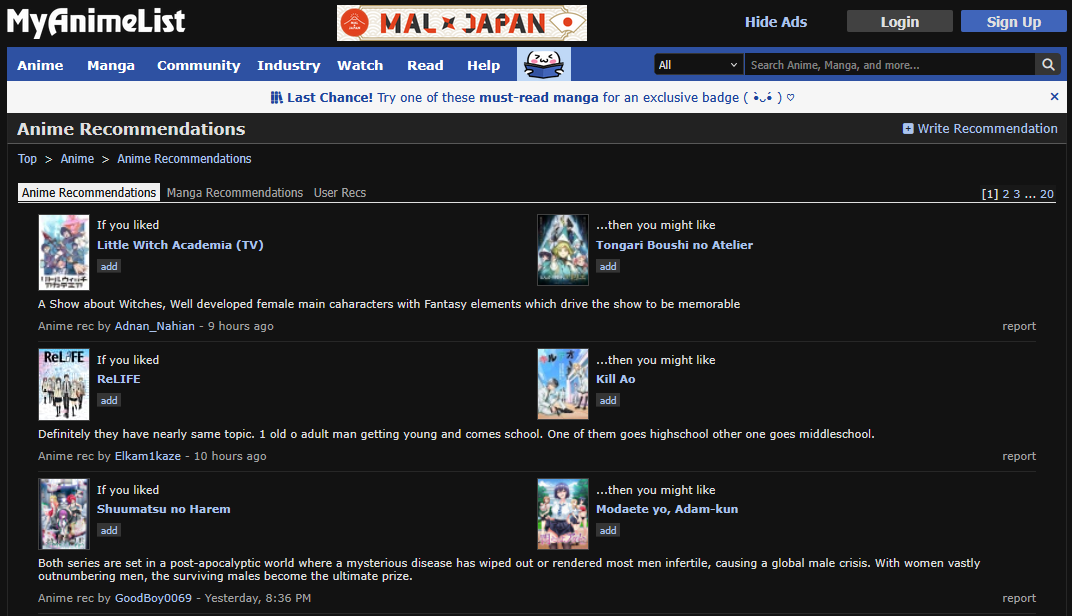

**What this notebook covers:**
1. **Data loading & cleaning**: handling 80M+ ratings, filtering thresholds, sparsity analysis
2. **Exploratory data analysis**: genre co-occurrence, rating biases, user/anime activity distributions
3. **Content-based filtering**: one-hot encoded genre vectors + cosine similarity
4. **Collaborative filtering**: SVD vs NMF, bias correction, hyperparameter tuning
5. **Hybrid model**: why naive score blending failed, and how rank-based fusion fixed it
6. **Summary**: final model comparison and next steps

**Dataset:** [MyAnimeList Dataset on Kaggle](https://www.kaggle.com/datasets/azathoth42/myanimelist): ~14K anime, ~300K users, ~80M ratings.
The dataset consists of three CSV files: AnimeList.csv, UserList.csv and UserAnimeList.csv.

***Note** that I have only used static snapshots of the MAL datasets purely for demo purposes and due to limited computation. This proof of concept can be scaled for the live dataset and integrated into their website.

**Tech stack:** Python, pandas, NumPy, scikit-learn, scikit-surprise, matplotlib, seaborn

## **Part 1: Data Loading & Cleaning**

In [ ]:
# Import statements
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.max_columns", 40)

In [ ]:
# Google Colab setup to mount drives for data
from google.colab import drive
drive.mount('/content/drive')
data_dir = "/content/mal_data"

Mounted at /content/drive


In [ ]:
anime_df = pd.read_csv(f"{data_dir}/AnimeList.csv")
user_df = pd.read_csv(f"{data_dir}/UserList.csv")

# Only using a sample of UserAnimeList.csv as it contains 80M rows of individual user-anime interactions
ratings_df = pd.read_csv(f"{data_dir}/UserAnimeList_sample.csv")

print(f"AnimeList shape:     {anime_df.shape}")
print(f"UserList shape:      {user_df.shape}")
print(f"UserAnimeList shape: {ratings_df.shape}")


AnimeList shape:     (14478, 31)
UserList shape:      (302675, 17)
UserAnimeList shape: (911212, 11)


In [ ]:
anime_df.head(3)

,anime_id,title,title_english,title_japanese,title_synonyms,image_url,type,source,episodes,status,airing,aired_string,aired,duration,rating,score,scored_by,rank,popularity,members,favorites,background,premiered,broadcast,related,producer,licensor,studio,genre,opening_theme,ending_theme
0,11013,Inu x Boku SS,Inu X Boku Secret Service,妖狐×僕SS,Youko x Boku SS,https://myanimelist.cdn-dena.com/images/anime/...,TV,Manga,12,Finished Airing,False,"Jan 13, 2012 to Mar 30, 2012","{'from': '2012-01-13', 'to': '2012-03-30'}",24 min. per ep.,PG-13 - Teens 13 or older,7.63,139250,1274.0,231,283882,2809,Inu x Boku SS was licensed by Sentai Filmworks...,Winter 2012,Fridays at Unknown,"{'Adaptation': [{'mal_id': 17207, 'type': 'man...","Aniplex, Square Enix, Mainichi Broadcasting Sy...",Sentai Filmworks,David Production,"Comedy, Supernatural, Romance, Shounen","['""Nirvana"" by MUCC']","['#1: ""Nirvana"" by MUCC (eps 1, 11-12)', '#2: ..."
1,2104,Seto no Hanayome,My Bride is a Mermaid,瀬戸の花嫁,The Inland Sea Bride,https://myanimelist.cdn-dena.com/images/anime/...,TV,Manga,26,Finished Airing,False,"Apr 2, 2007 to Oct 1, 2007","{'from': '2007-04-02', 'to': '2007-10-01'}",24 min. per ep.,PG-13 - Teens 13 or older,7.89,91206,727.0,366,204003,2579,NaN,Spring 2007,Unknown,"{'Adaptation': [{'mal_id': 759, 'type': 'manga...","TV Tokyo, AIC, Square Enix, Sotsu",Funimation,Gonzo,"Comedy, Parody, Romance, School, Shounen","['""Romantic summer"" by SUN&LUNAR']","['#1: ""Ashita e no Hikari (明日への光)"" by Asuka Hi..."
2,5262,Shugo Chara!! Doki,Shugo Chara!! Doki,しゅごキャラ！！どきっ,"Shugo Chara Ninenme, Shugo Chara! Second Year",https://myanimelist.cdn-dena.com/images/anime/...,TV,Manga,51,Finished Airing,False,"Oct 4, 2008 to Sep 25, 2009","{'from': '2008-10-04', 'to': '2009-09-25'}",24 min. per ep.,PG - Children,7.55,37129,1508.0,1173,70127,802,NaN,Fall 2008,Unknown,"{'Adaptation': [{'mal_id': 101, 'type': 'manga...","TV Tokyo, Sotsu",NaN,Satelight,"Comedy, Magic, School, Shoujo","['#1: ""Minna no Tamago (みんなのたまご)"" by Shugo Cha...","['#1: ""Rottara Rottara (ロッタラ ロッタラ)"" by Buono! ..."


In [ ]:
anime_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14478 entries, 0 to 14477
Data columns (total 31 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   anime_id        14478 non-null  int64  
 1   title           14478 non-null  object 
 2   title_english   5724 non-null   object 
 3   title_japanese  14443 non-null  object 
 4   title_synonyms  8937 non-null   object 
 5   image_url       14382 non-null  object 
 6   type            14478 non-null  object 
 7   source          14478 non-null  object 
 8   episodes        14478 non-null  int64  
 9   status          14478 non-null  object 
 10  airing          14478 non-null  bool   
 11  aired_string    14478 non-null  object 
 12  aired           14478 non-null  object 
 13  duration        14478 non-null  object 
 14  rating          13934 non-null  object 
 15  score           14478 non-null  float64
 16  scored_by       14478 non-null  int64  
 17  rank            12904 non-null 

In [ ]:
user_df.head(3)

,username,user_id,user_watching,user_completed,user_onhold,user_dropped,user_plantowatch,user_days_spent_watching,gender,location,birth_date,access_rank,join_date,last_online,stats_mean_score,stats_rewatched,stats_episodes
0,karthiga,2255153,3,49,1,0,0,55.31,Female,"Chennai, India",1990-04-29,NaN,2013-03-03,2014-02-04 01:32:00,7.43,0.0,3391.0
1,RedvelvetDaisuki,1897606,61,396,39,0,206,118.07,Female,Manila,1995-01-01,NaN,2012-12-13,1900-05-13 02:47:00,6.78,80.0,7094.0
2,Damonashu,37326,45,195,27,25,59,83.70,Male,"Detroit,Michigan",1991-08-01,NaN,2008-02-13,1900-03-24 12:48:00,6.15,6.0,4936.0


In [ ]:
user_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302675 entries, 0 to 302674
Data columns (total 17 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   username                  302674 non-null  object 
 1   user_id                   302675 non-null  int64  
 2   user_watching             302675 non-null  int64  
 3   user_completed            302675 non-null  int64  
 4   user_onhold               302675 non-null  int64  
 5   user_dropped              302675 non-null  int64  
 6   user_plantowatch          302675 non-null  int64  
 7   user_days_spent_watching  302675 non-null  float64
 8   gender                    217800 non-null  object 
 9   location                  156773 non-null  object 
 10  birth_date                168749 non-null  object 
 11  access_rank               0 non-null       float64
 12  join_date                 302546 non-null  object 
 13  last_online               302546 non-null  o

In [ ]:
ratings_df.head(3)

,username,anime_id,my_watched_episodes,my_start_date,my_finish_date,my_score,my_status,my_rewatching,my_rewatching_ep,my_last_updated,my_tags
0,karthiga,21,586,0000-00-00,0000-00-00,9,1,NaN,0,1362307973,NaN
1,karthiga,59,26,0000-00-00,0000-00-00,7,2,NaN,0,1362923691,NaN
2,karthiga,74,26,0000-00-00,0000-00-00,7,2,NaN,0,1367081015,NaN


In [ ]:
ratings_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 911212 entries, 0 to 911211
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   username             911212 non-null  object 
 1   anime_id             911212 non-null  int64  
 2   my_watched_episodes  911212 non-null  int64  
 3   my_start_date        911212 non-null  object 
 4   my_finish_date       911212 non-null  object 
 5   my_score             911212 non-null  int64  
 6   my_status            911212 non-null  int64  
 7   my_rewatching        719274 non-null  float64
 8   my_rewatching_ep     911212 non-null  int64  
 9   my_last_updated      911212 non-null  int64  
 10  my_tags              82855 non-null   object 
dtypes: float64(1), int64(6), object(4)
memory usage: 76.5+ MB


### Cleaning anime_df (AnimeList.csv)

AnimeList.csv is the backbone of content-based filtering. I need to handle dirty genre strings, missing scores, or unaired anime as they would pollute the feature vectors and similarity calculations. Hence my strategy to clean this file is to:

Drop anime that haven't aired yet (no ratings or engagement data exist)

In [ ]:
print(f"Starting anime count: {len(anime_df)}")

# Check the 'status' column for airing information
print(anime_df["status"].value_counts())

# Removing rows if 'status' contains "Not yet aired"
anime_clean = anime_df[anime_df["status"] != "Not yet aired"].copy()
print(f"After removing not-yet-aired: {len(anime_clean)}")

Starting anime count: 14478
status
Finished Airing     13791
Currently Airing      351
Not yet aired         336
Name: count, dtype: int64
After removing not-yet-aired: 14142


Drop anime with no genre listed (genre is a primary content feature)

In [ ]:
print(f"Null genres: {anime_clean['genre'].isna().sum()}")
print(f"'Unknown' genres: {(anime_clean['genre'] == 'Unknown').sum()}")

anime_clean = anime_clean[anime_clean["genre"].notna() & (anime_clean["genre"] != "Unknown")]
print(f"After removing missing genres: {len(anime_clean)}")


Null genres: 56
'Unknown' genres: 0
After removing missing genres: 14086


Drop anime with score = 0 or NaN (insufficient community ratings)

In [ ]:
print(f"Zero scores: {(anime_clean['score'] == 0).sum()}")
print(f"NaN scores:  {anime_clean['score'].isna().sum()}")

anime_clean = anime_clean[anime_clean["score"].notna() & (anime_clean["score"] > 0)]
print(f"After removing zero/null scores: {len(anime_clean)}")


Select only the columns needed below which contain identifiers, content features, and popularity signals.

In [ ]:
ANIME_COLS = [
    "anime_id",
    "title",
    "title_english",
    "type",        # TV, Movie, OVA, etc.
    "source",      # Manga, Light novel, Original, etc.
    "episodes",
    "status",
    "aired",
    "duration",
    "rating",      # Age rating (PG-13, R, etc.)
    "score",       # Community average score
    "scored_by",   # Number of users who scored it
    "members",     # Number of MAL members who have it on their list
    "favorites",
    "genre",       # Pipe-separated genre string
    "studio",
    "premiered",
]

available_cols = [c for c in ANIME_COLS if c in anime_clean.columns]
anime_clean = anime_clean[available_cols].copy()

print(f"\nFinal anime_clean shape: {anime_clean.shape}")
anime_clean.head()



Final anime_clean shape: (14068, 17)


,anime_id,title,title_english,type,source,episodes,status,aired,duration,rating,score,scored_by,members,favorites,genre,studio,premiered
0,11013,Inu x Boku SS,Inu X Boku Secret Service,TV,Manga,12,Finished Airing,"{'from': '2012-01-13', 'to': '2012-03-30'}",24 min. per ep.,PG-13 - Teens 13 or older,7.63,139250,283882,2809,"Comedy, Supernatural, Romance, Shounen",David Production,Winter 2012
1,2104,Seto no Hanayome,My Bride is a Mermaid,TV,Manga,26,Finished Airing,"{'from': '2007-04-02', 'to': '2007-10-01'}",24 min. per ep.,PG-13 - Teens 13 or older,7.89,91206,204003,2579,"Comedy, Parody, Romance, School, Shounen",Gonzo,Spring 2007
2,5262,Shugo Chara!! Doki,Shugo Chara!! Doki,TV,Manga,51,Finished Airing,"{'from': '2008-10-04', 'to': '2009-09-25'}",24 min. per ep.,PG - Children,7.55,37129,70127,802,"Comedy, Magic, School, Shoujo",Satelight,Fall 2008
3,721,Princess Tutu,Princess Tutu,TV,Original,38,Finished Airing,"{'from': '2002-08-16', 'to': '2003-05-23'}",16 min. per ep.,PG-13 - Teens 13 or older,8.21,36501,93312,3344,"Comedy, Drama, Magic, Romance, Fantasy",Hal Film Maker,Summer 2002
4,12365,Bakuman. 3rd Season,Bakuman.,TV,Manga,25,Finished Airing,"{'from': '2012-10-06', 'to': '2013-03-30'}",24 min. per ep.,PG-13 - Teens 13 or older,8.67,107767,182765,2082,"Comedy, Drama, Romance, Shounen",J.C.Staff,Fall 2012


I noticed the 'title_english' column had missing values however, they still had original title names. I did not want to simply drop these as a significant portion of the data would have to be omitted. Instead, I chose to backfill with the original title to preserve catalog coverage while ensuring every anime has a displayable name for later on.

In [ ]:
# Fill missing English titles with the original title
anime_clean["title_english"] = anime_clean["title_english"].fillna(anime_clean["title"])

print(f"Remaining NaN in title_english: {anime_clean['title_english'].isna().sum()}")

Remaining NaN in title_english: 0


For content based filtering, I need to split the Genres into separate features. The column uses incosistent delimters '|' and ',' both. I use a regex split to correctly separate the genres.

In [ ]:
# Split on both pipe and comma, then strip whitespace
all_genres = anime_clean["genre"].str.split(r"[|,]").explode().str.strip()

# Remove any empty strings that might result from double separators
all_genres = all_genres[all_genres != ""]

genre_counts = all_genres.value_counts()
print(f"Total unique genres: {genre_counts.shape[0]}\n")
print(genre_counts.head(20))

Total unique genres: 43

genre
Comedy           5141
Action           3114
Fantasy          2619
Adventure        2521
Drama            2227
Sci-Fi           2207
Kids             1988
Shounen          1732
Romance          1597
Slice of Life    1485
School           1355
Music            1324
Hentai           1211
Supernatural     1170
Mecha             985
Historical        939
Magic             896
Ecchi             676
Seinen            670
Shoujo            630
Name: count, dtype: int64


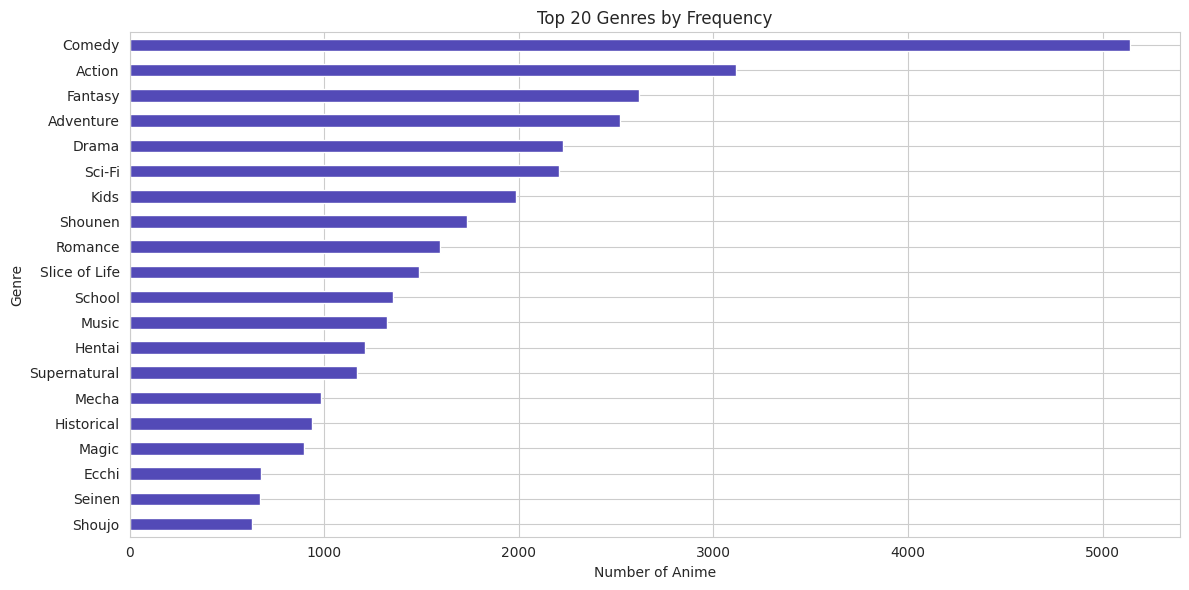

In [ ]:
# Visualize the genre distribution
fig, ax = plt.subplots(figsize=(12, 6))
genre_counts.head(20).plot(kind="barh", ax=ax, color="#534AB7")
ax.set_xlabel("Number of Anime")
ax.set_ylabel("Genre")
ax.set_title("Top 20 Genres by Frequency")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("genre_distribution.png", dpi=150, bbox_inches="tight")
plt.show()




---



### Cleaning ratings_df (UserAnimeList_sample.csv)

In this file, I found these few issues that I need to address in cleaning:



1.   Users have scores of 0 for anime that they have not yet rated. The anime is on their list, but they haven't assigned it a score yet. For the explicit-rating CF models (SVD, NMF) we must filter these out. However, we can draw that the user was interested enough to add it to their list. We can use this information later.
2.   Some users only gave 1 or 2 ratings which does not provide enough signal for CF and instead adds noise to the user-item matrix.
3.   Anime that has only a handful of user ratings cannot be reliably recommended via CF.
4.   Only keep anime that survived from the previous anime_df cleaning step.


In [ ]:
print(f"Starting ratings count: {len(ratings_df)}")
print(f"\nColumns: {ratings_df.columns.tolist()}")
print(f"\nmy_score distribution:")
print(ratings_df["my_score"].value_counts().sort_index())

Starting ratings count: 911212

Columns: ['username', 'anime_id', 'my_watched_episodes', 'my_start_date', 'my_finish_date', 'my_score', 'my_status', 'my_rewatching', 'my_rewatching_ep', 'my_last_updated', 'my_tags']

my_score distribution:
my_score
0     370288
1       3083
2       4913
3       8624
4      17003
5      35717
6      65308
7     123592
8     130386
9      88867
10     63431
Name: count, dtype: int64


I want to remove all the unrated entries

In [ ]:
zero_pct = (ratings_df["my_score"] == 0).mean() * 100
print(f"Percentage of my_score == 0: {zero_pct:.1f}%")

ratings_clean = ratings_df[ratings_df["my_score"] > 0].copy()
print(f"After removing unrated: {len(ratings_clean)} ({len(ratings_clean)/len(ratings_df)*100:.1f}% retained)")

Percentage of my_score == 0: 40.6%
After removing unrated: 540924 (59.4% retained)


Join against our anime_clean dataset to drop orphaned ratings

In [ ]:
valid_anime_ids = set(anime_clean["anime_id"].unique())
before = len(ratings_clean)
ratings_clean = ratings_clean[ratings_clean["anime_id"].isin(valid_anime_ids)]
print(f"Dropped {before - len(ratings_clean)} ratings for removed anime")
print(f"Remaining: {len(ratings_clean)}")

Dropped 102 ratings for removed anime
Remaining: 540822


Let's create some activity thresholds and filter.
Minimum ratings per ***user*** removes casual users with insufficient data. Minimum ratings per ***anime*** removes obscure anime with insufficient data.

Higher thresholds mean we get a denser matrix and better CF accuracy at the expense of coverage. Lower thresholds mean we get a sparser matrix for more coverage however noisier predictions. We can tweak these based on the model performance.

In [ ]:
MIN_RATINGS_PER_USER = 20   # user must have rated at least 20 anime
MIN_RATINGS_PER_ANIME = 50  # anime must have at least 50 ratings

In [ ]:
# Filter users
user_counts = ratings_clean["username"].value_counts()
active_users = set(user_counts[user_counts >= MIN_RATINGS_PER_USER].index)
print(f"Users with >= {MIN_RATINGS_PER_USER} ratings: {len(active_users)} "f"(out of {ratings_clean['username'].nunique()})")

ratings_clean = ratings_clean[ratings_clean["username"].isin(active_users)]

Users with >= 20 ratings: 2337 (out of 2701)


With our 2M row sample, the 50-rating minimum retains only 23% of anime. On the full dataset this will be significantly higher, since each anime will have ~40x more rating records available

In [ ]:
# Filter anime
anime_counts = ratings_clean["anime_id"].value_counts()
popular_anime = set(anime_counts[anime_counts >= MIN_RATINGS_PER_ANIME].index)
print(f"Anime with >= {MIN_RATINGS_PER_ANIME} ratings: {len(popular_anime)} "f"(out of {ratings_clean['anime_id'].nunique()})")

ratings_clean = ratings_clean[ratings_clean["anime_id"].isin(popular_anime)]

print(f"\nFinal ratings shape: {ratings_clean.shape}")
print(f"Unique users:  {ratings_clean['username'].nunique()}")
print(f"Unique anime:  {ratings_clean['anime_id'].nunique()}")


Anime with >= 50 ratings: 2460 (out of 10907)

Final ratings shape: (457086, 11)
Unique users:  2337
Unique anime:  2460


I am computing the sparisty of the user-item matrix to find out how empty it is. Most real-world recommender matrices are 95-99.5% sparse.

In [ ]:
n_users = ratings_clean["username"].nunique()
n_anime = ratings_clean["anime_id"].nunique()
n_ratings = len(ratings_clean)
sparsity = 1 - (n_ratings / (n_users * n_anime))

print(f"User-Item Matrix Dimensions: {n_users} users × {n_anime} anime")
print(f"Total possible entries:      {n_users * n_anime:,}")
print(f"Actual ratings:              {n_ratings:,}")
print(f"Sparsity:                    {sparsity:.4%}")


User-Item Matrix Dimensions: 2337 users × 2460 anime
Total possible entries:      5,749,020
Actual ratings:              457,086
Sparsity:                    92.0493%


At 92% sparsity, the cleaned matrix is relatively dense for a recommender system. This is partly because I am using a 2M row sample and applying activity thresholds. I've essentially selected the most engaged users and most popular anime. On the full dataset with relaxed thresholds, expect sparsity to climb toward 98-99%, which will make matrix factorization methods (SVD, NMF) more important relative to memory-based approaches.



---



### Cleaning user_df (UserList.csv)

While this isn't entirely needed for basic CF or content-based filtering, I wanted to use the data in here for cold-start handling, segmentation analysis and feature enrichment if possible.

In [ ]:
print(f"Starting user count: {len(user_df)}")
print(f"\nGender distribution:")
print(user_df["gender"].value_counts(dropna=False).head())

# %%
# Keep only users who survived our ratings filtering
active_usernames = set(ratings_clean["username"].unique())
user_clean = user_df[user_df["username"].isin(active_usernames)].copy()
print(f"Users with active ratings: {len(user_clean)}")

# Basic demographic cleaning
user_clean["gender"] = user_clean["gender"].fillna("Unknown")

Starting user count: 302675

Gender distribution:
gender
Male          135181
NaN            84875
Female         81374
Non-Binary      1245
Name: count, dtype: int64
Users with active ratings: 2336


Rating distribution analysis

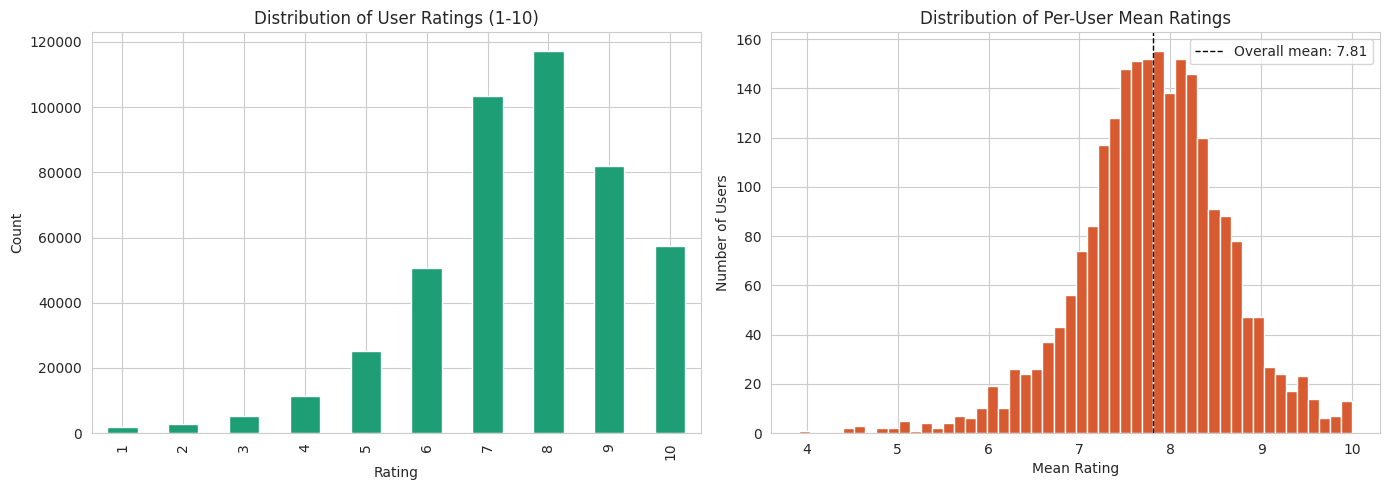


Overall mean rating: 7.59
Median rating:       8
Std deviation:       1.67


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall score distribution
ratings_clean["my_score"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="#1D9E75", edgecolor="white"
)
axes[0].set_title("Distribution of User Ratings (1-10)")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")

# Mean rating per user
user_means = ratings_clean.groupby("username")["my_score"].mean()
axes[1].hist(user_means, bins=50, color="#D85A30", edgecolor="white")
axes[1].set_title("Distribution of Per-User Mean Ratings")
axes[1].set_xlabel("Mean Rating")
axes[1].set_ylabel("Number of Users")
axes[1].axvline(user_means.mean(), color="black", linestyle="--", linewidth=1,
                label=f"Overall mean: {user_means.mean():.2f}")
axes[1].legend()

plt.tight_layout()
plt.savefig("rating_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nOverall mean rating: {ratings_clean['my_score'].mean():.2f}")
print(f"Median rating:       {ratings_clean['my_score'].median():.0f}")
print(f"Std deviation:       {ratings_clean['my_score'].std():.2f}")



Left plot shows individual ratings. Most of the ratings are between 6-9, with 8 being the modal rating. Ratings 1-4 are rare, meaning that people mostly rate things they enjoyed. If they dislike something, they're more likely to drop it and never score it than to give it a 2.

The right plot shows per-user means and essentially that different users use the scale differently. The overall mean is 7.81, however we can see some users average around 5 or even past 9. This means we need to use mean-centering per user when building the CF models. Instead of raw scores we subtract each user's mean to get their mean-centered score.

In [ ]:
anime_clean.to_csv(f"{data_dir}anime_clean.csv", index=False)
ratings_clean.to_csv(f"{data_dir}ratings_clean.csv", index=False)
user_clean.to_csv(f"{data_dir}user_clean.csv", index=False)

print("Saved:")
print(f"  anime_clean.csv   — {anime_clean.shape}")
print(f"  ratings_clean.csv — {ratings_clean.shape}")
print(f"  user_clean.csv    — {user_clean.shape}")


Saved:
  anime_clean.csv   — (14068, 17)
  ratings_clean.csv — (457086, 11)
  user_clean.csv    — (2336, 17)


## **Part 2: Exploratory Data Analysis (EDA)**

Before building models, I want to understand three things about this data:

1. **Which genres tend to appear together?** If two genres almost always co-occur, they're essentially redundant features. This affects how well content-based filtering can distinguish between anime.

2. **Do some genres consistently get higher ratings?** If "Thriller" averages 8.1 and "Kids" averages 6.3, a naive recommender would systematically steer users away from Kids anime even if they love that genre.

3. **How are ratings distributed across users and anime?** Power users with 1,000+ ratings vs. casual users with 20 ratings will affect which modeling approaches work best.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 40)

anime_clean = pd.read_csv("anime_clean.csv")
ratings_clean = pd.read_csv("ratings_clean.csv")

print(f"Anime: {len(anime_clean)}  |  Ratings: {len(ratings_clean)}")

Anime: 14068  |  Ratings: 457086


### Genre co-occurrence analysis

To understand which genres appear together, I'll one-hot encode the genres and compute a co-occurrence matrix. Multiplying the genre matrix by its transpose (G^T x G) gives us a count of how many anime share each pair of genres. I'll then normalize this using Jaccard similarity to account for genre popularity differences.

One-hot encoding the genres to get additional features:

In [ ]:
# One-hot encode genres
genre_split = anime_clean["genre"].str.split(r"[|,]").apply(
    lambda x: [g.strip() for g in x] if isinstance(x, list) else []
)
from sklearn.preprocessing import MultiLabelBinarizer

# takes a list-of-lists and produces the one-hot matrix automatically
mlb = MultiLabelBinarizer()
genre_matrix = pd.DataFrame(
    mlb.fit_transform(genre_split),
    columns=mlb.classes_,
    index=anime_clean["anime_id"],
)

print(f"Shape: {genre_matrix.shape}")
print(f"First 3 anime and first 8 genres:")
genre_matrix.iloc[:3, :8]

Shape: (14068, 43)
First 3 anime and first 8 genres:


,Action,Adventure,Cars,Comedy,Dementia,Demons,Drama,Ecchi
anime_id,,,,,,,,
11013,0,0,0,1,0,0,0,0
2104,0,0,0,1,0,0,0,0
5262,0,0,0,1,0,0,0,0


In [ ]:
# Genre co-occurrence: G^T × G
co_occurrence = genre_matrix.T.dot(genre_matrix)
print(f"Shape: {co_occurrence.shape}")
print(f"\nAnime that have both Action and Adventure:")
print(f"  Action ∩ Adventure: {co_occurrence.loc['Action', 'Adventure']}")
print(f"  Action total:       {co_occurrence.loc['Action', 'Action']}")
print(f"  Adventure total:    {co_occurrence.loc['Adventure', 'Adventure']}")

Shape: (43, 43)

Anime that have both Action and Adventure:
  Action ∩ Adventure: 983
  Action total:       3114
  Adventure total:    2521


Normalize co-occurrence into Jaccard similarity
Jaccard(A,B) = |A ∩ B| / |A ∪ B|  

|A ∪ B| = |A| + |B| - |A ∩ B|

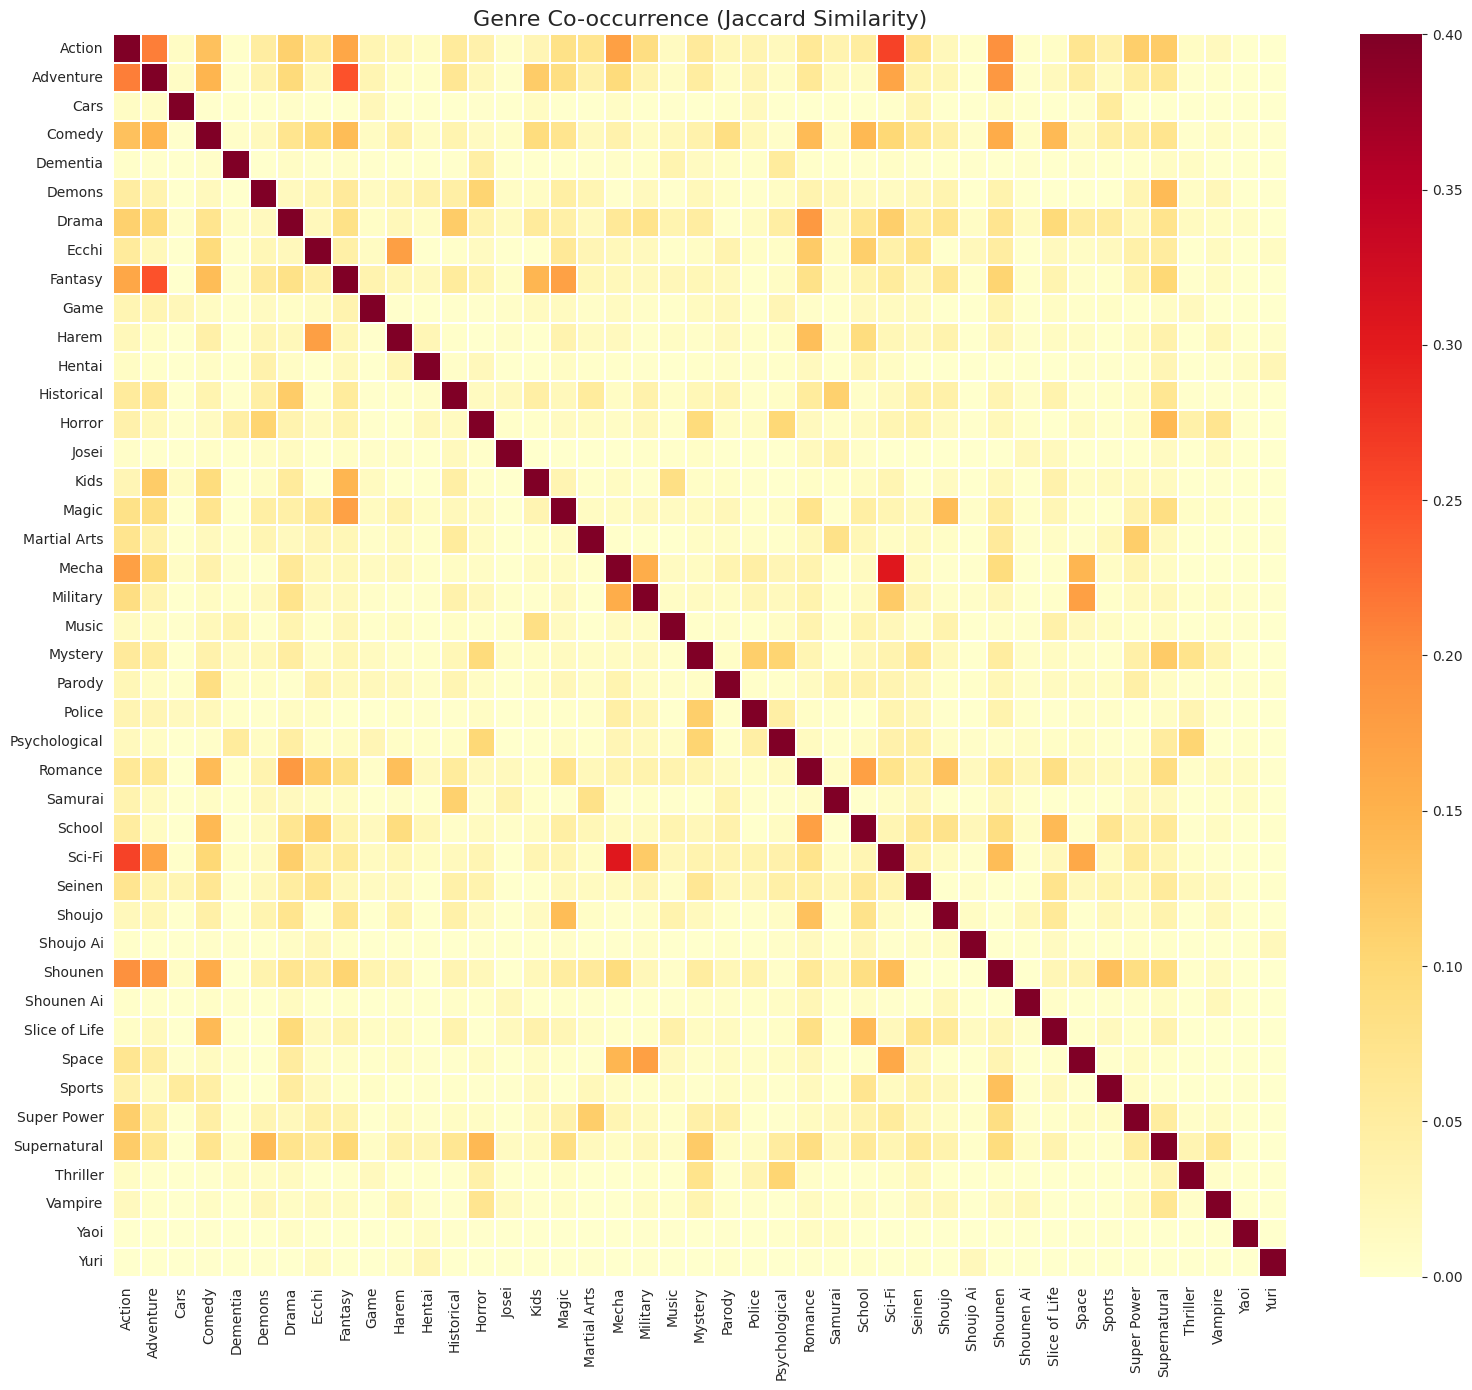

In [ ]:
diag = np.diag(co_occurrence)  # genre totals along the diagonal
# Broadcast: union(i,j) = total_i + total_j - intersection(i,j)
union_matrix = diag[:, None] + diag[None, :] - co_occurrence.values
jaccard = co_occurrence.values / union_matrix

jaccard_df = pd.DataFrame(jaccard, index=co_occurrence.index, columns=co_occurrence.columns)

# Plot
fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    jaccard_df,
    cmap="YlOrRd",
    vmin=0, vmax=0.4,
    linewidths=0.1,
    ax=ax,
)
ax.set_title("Genre Co-occurrence (Jaccard Similarity)", fontsize=16)
plt.tight_layout()
plt.savefig("genre_cooccurrence_jaccard.png", dpi=150, bbox_inches="tight")
plt.show()

From the heatmap we can see that Sci-Fi x Mecha is a strong pair and makes sense. Adventure x Fantasy, Shounen x Action, Psychological x Thriller are other examples of good pairs.

### Rating distribution by genre

Next I want to check whether some genres are systematically rated higher or lower than others. This matters because if there's a 2-point gap between genres, a naive recommender would favor "prestige" genres regardless of user preference. Understanding this bias informs whether I need to normalize scores by genre during modeling.

In [ ]:
# Build a long-form table: one row per (anime_id, genre)
anime_genres = anime_clean[["anime_id", "genre"]].copy()
anime_genres["genre"] = anime_genres["genre"].str.split(r"[|,]")
anime_genres = anime_genres.explode("genre")
anime_genres["genre"] = anime_genres["genre"].str.strip()

# Merge with ratings to get individual user scores per genre
genre_ratings = ratings_clean[["anime_id", "my_score"]].merge(anime_genres, on="anime_id")

print(f"Rows: {len(genre_ratings):,}")
print(f"Unique genres: {genre_ratings['genre'].nunique()}")
genre_ratings.head()

Rows: 2,089,783
Unique genres: 43


,anime_id,my_score,genre
0,21,9,Action
1,21,9,Adventure
2,21,9,Comedy
3,21,9,Super Power
4,21,9,Drama


In [ ]:
# Mean rating by genre, sorted
genre_means = genre_ratings.groupby("genre")["my_score"].agg(["mean", "count", "std"])
genre_means = genre_means.sort_values("mean", ascending=False)
print(genre_means.head(10))
print("\n...")
print(genre_means.tail(10))

                   mean  count       std
genre                                   
Thriller       8.138754  19394  1.507294
Cars           8.062665   1133  1.341295
Police         7.965915   9183  1.594901
Samurai        7.964310   7285  1.641994
Historical     7.931830  24439  1.553957
Military       7.895868  29213  1.594970
Dementia       7.870525   5754  1.753472
Josei          7.853746   6687  1.563061
Psychological  7.826136  37006  1.684116
Sports         7.823454  14914  1.597586

...
                  mean  count       std
genre                                  
Shounen Ai    7.465378   3105  1.878607
Horror        7.431433  24713  1.839154
Martial Arts  7.388681  14948  1.749208
Kids          7.140772   5754  1.609764
Harem         7.118276  41234  1.733585
Shoujo Ai     7.088450   5065  1.696710
Ecchi         7.075037  56932  1.779513
Yuri          6.782258    248  1.824531
Yaoi          6.488502   1435  2.392247
Hentai        6.283500   1097  2.436948


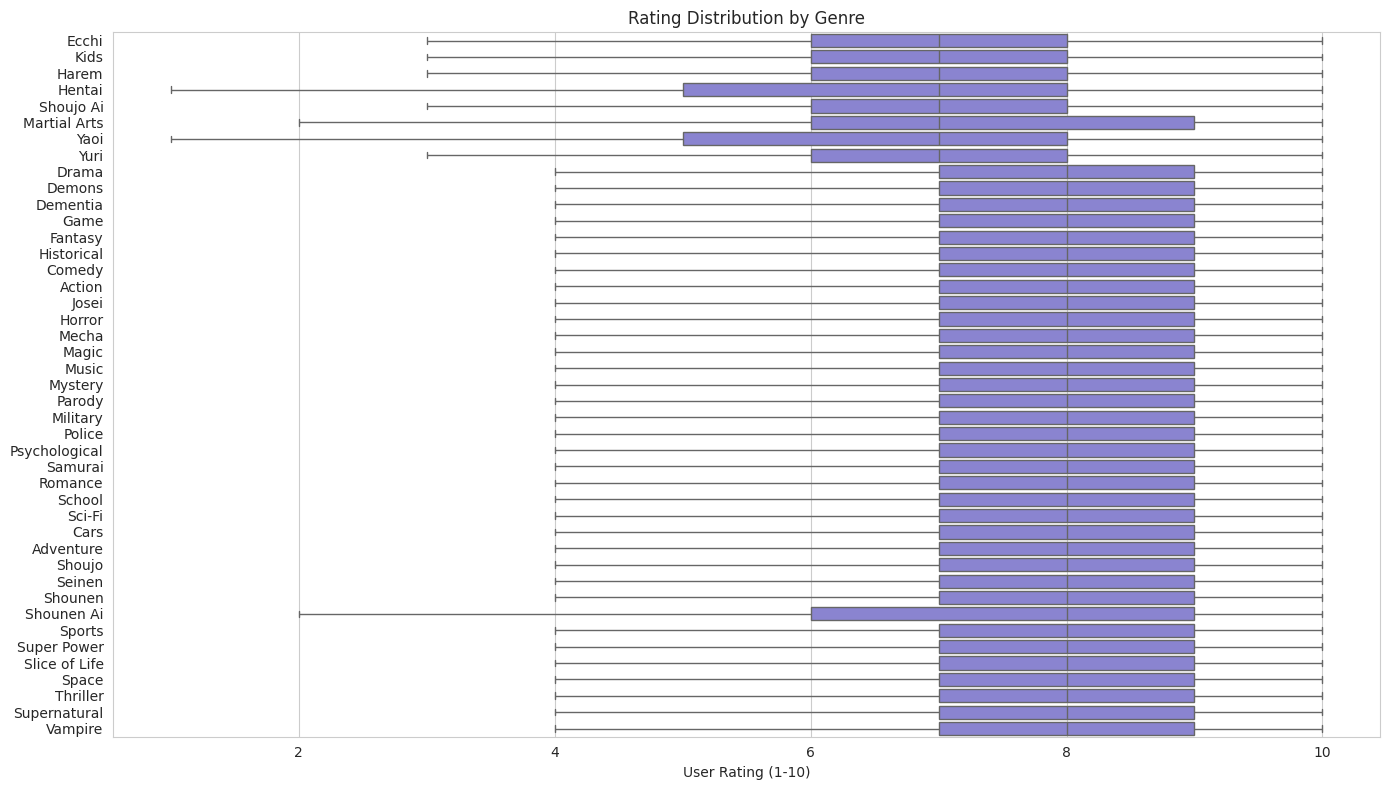

In [ ]:
# Order genres by median rating for the plot
genre_order = genre_ratings.groupby("genre")["my_score"].median().sort_values().index

fig, ax = plt.subplots(figsize=(14, 8))
sns.boxplot(
    data=genre_ratings,
    x="my_score",
    y="genre",
    order=genre_order,
    color="#7F77DD",
    fliersize=0,
    ax=ax,
)
ax.set_title("Rating Distribution by Genre")
ax.set_xlabel("User Rating (1-10)")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("genre_rating_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

Genre-level rating biases range nearly 2 points (Kids ~ 6.3 to Thriller ~8.1). Polarizing genres like Yaoi and Hentai show high variance (std > 2.3) while prestige genres like Thriller and Police show tigheter consensus (std ~1.5). This confirms that raw scores carry genre-level bias, motivating score normalization in the modeling phase.

### User and anime activity distributions

The "long tail" is a well-known pattern in recommender systems where a small number of items receive most of the ratings, while the majority have very few. Understanding the shape of this distribution tells me whether memory based collaborative filtering (which needs dense neighborhoods) will work, or whether I need matrix factorization methods that handle sparsity better.

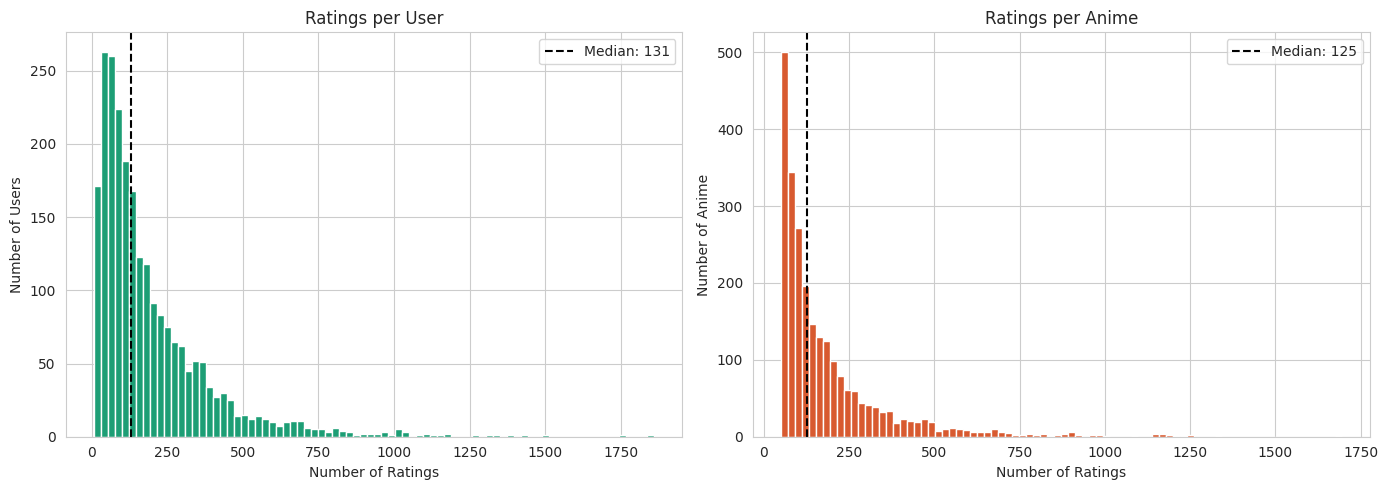

In [ ]:
user_activity = ratings_clean.groupby("username")["my_score"].count()
anime_popularity = ratings_clean.groupby("anime_id")["my_score"].count()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(user_activity, bins=80, color="#1D9E75", edgecolor="white")
axes[0].set_title("Ratings per User")
axes[0].set_xlabel("Number of Ratings")
axes[0].set_ylabel("Number of Users")
axes[0].axvline(user_activity.median(), color="black", linestyle="--", label=f"Median: {user_activity.median():.0f}")
axes[0].legend()

axes[1].hist(anime_popularity, bins=80, color="#D85A30", edgecolor="white")
axes[1].set_title("Ratings per Anime")
axes[1].set_xlabel("Number of Ratings")
axes[1].set_ylabel("Number of Anime")
axes[1].axvline(anime_popularity.median(), color="black", linestyle="--", label=f"Median: {anime_popularity.median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.savefig("activity_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

**Left plot:** Majority of the users have rated 50-200 anime with a median of 131. But there is a long tail stretching past 1000 indicating the power users who have watched and rated thousands of titles. This should drive most of the CF signal.

**Right plot:** Most anime cluster near the 50-200 range (given that the minimum threshold was 50), and a handful of renowned blockbusters have 1000+ ratings.

Both users and anime follow a power-law distribution. A small number of popular anime and power users account for a disproportionate share of ratings. This popularity bias means collaborative filtering alone will over-recommend popular titles. A hybrid approach can mitigate this by using content features to surface quality niche anime.

## **Part 3: Building the models**

I'm building three approaches and comparing them systematically:

1. **Content-based filtering**: recommends anime similar to what you've watched, based on genre profiles. No other users needed.
2. **Collaborative filtering (SVD & NMF)**: learns latent taste patterns from the entire user-rating matrix. Captures "users who liked X also liked Y" even when X and Y share no genres.
3. **Hybrid**: combines both approaches to get the best of both worlds.

I want to understand why each model works or fails on this specific dataset and use that knowledge to help me decide on the best model ultimately.

### Content-based filtering

For this approach, I want to represent each anime as a vector of its genres (one-hot encoded), then measure similarity between anime using cosine similarity. If a user liked Anime A, recommend anime with the highest cosine similarity to A.

I am using cosine similarity here as it measures the angle between two vectors, not the distance. This means an anime with 6 genres and one with 2 genres can still have high similarity if those 2 genres are a subset of the 6. Euclidean distance would penalize the difference in genre count.

For binary vectors (this case), the formula simplifies to:
cosine_sim(A, B) = (genres they share) / (sqrt(genres in A) × sqrt(genres in B))

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics.pairwise import cosine_similarity

anime_clean = pd.read_csv("anime_clean.csv")
ratings_clean = pd.read_csv("ratings_clean.csv")

print(f"Anime: {len(anime_clean)}  |  Ratings: {len(ratings_clean)}")

Anime: 14068  |  Ratings: 457086


Doing a quick sanity check of the cleaned data:

In [ ]:
anime_clean

,anime_id,title,title_english,type,source,episodes,status,aired,duration,rating,score,scored_by,members,favorites,genre,studio,premiered
0,11013,Inu x Boku SS,Inu X Boku Secret Service,TV,Manga,12,Finished Airing,"{'from': '2012-01-13', 'to': '2012-03-30'}",24 min. per ep.,PG-13 - Teens 13 or older,7.63,139250,283882,2809,"Comedy, Supernatural, Romance, Shounen",David Production,Winter 2012
1,2104,Seto no Hanayome,My Bride is a Mermaid,TV,Manga,26,Finished Airing,"{'from': '2007-04-02', 'to': '2007-10-01'}",24 min. per ep.,PG-13 - Teens 13 or older,7.89,91206,204003,2579,"Comedy, Parody, Romance, School, Shounen",Gonzo,Spring 2007
2,5262,Shugo Chara!! Doki,Shugo Chara!! Doki,TV,Manga,51,Finished Airing,"{'from': '2008-10-04', 'to': '2009-09-25'}",24 min. per ep.,PG - Children,7.55,37129,70127,802,"Comedy, Magic, School, Shoujo",Satelight,Fall 2008
3,721,Princess Tutu,Princess Tutu,TV,Original,38,Finished Airing,"{'from': '2002-08-16', 'to': '2003-05-23'}",16 min. per ep.,PG-13 - Teens 13 or older,8.21,36501,93312,3344,"Comedy, Drama, Magic, Romance, Fantasy",Hal Film Maker,Summer 2002
4,12365,Bakuman. 3rd Season,Bakuman.,TV,Manga,25,Finished Airing,"{'from': '2012-10-06', 'to': '2013-03-30'}",24 min. per ep.,PG-13 - Teens 13 or older,8.67,107767,182765,2082,"Comedy, Drama, Romance, Shounen",J.C.Staff,Fall 2012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14063,35040,Minna no Taabou Konnichiwa,Minna no Taabou Konnichiwa,OVA,Original,1,Finished Airing,"{'from': None, 'to': None}",20 min.,G - All Ages,6.75,4,40,0,Kids,NaN,NaN
14064,26089,Gutchonpa Omoshiro Hanashi,Gutchonpa Omoshiro Hanashi,TV,Unknown,5,Finished Airing,"{'from': '1987-11-05', 'to': '1988-11-04'}",8 min. per ep.,G - All Ages,5.50,6,76,0,Kids,NaN,Fall 1987
14065,21525,Geba Geba Shou Time!,Geba Geba Shou Time!,OVA,Unknown,1,Finished Airing,"{'from': '1986-03-21', 'to': '1986-03-21'}",25 min.,G - All Ages,4.60,5,90,0,Comedy,NaN,NaN
14066,34193,Nippon Mukashibanashi: Sannen Netarou,Nippon Mukashibanashi: Sannen Netarou,OVA,Other,1,Finished Airing,"{'from': None, 'to': None}",40 min.,G - All Ages,6.00,1,32,0,"Fantasy, Kids",NaN,NaN


In [ ]:
#One-hot encode genres
genre_split = anime_clean["genre"].str.split(r"[|,]").apply(
    lambda x: [g.strip() for g in x] if isinstance(x, list) else []
)

mlb = MultiLabelBinarizer()
genre_matrix = pd.DataFrame(
    mlb.fit_transform(genre_split),
    columns=mlb.classes_,
    index=anime_clean["anime_id"],
)

print(f"Genre matrix shape: {genre_matrix.shape}")

Genre matrix shape: (14068, 43)


Now I want to compute the full cosine similarity matrix. Every anime compared against every other anime. This produces a 14,068 × 14,068 matrix that we can look up instantly for any pair of anime.

In [ ]:
# Compute cosine similarity between all anime pairs
# This produces a (14068 × 14068) matrix - every anime vs every anime

cosine_sim = cosine_similarity(genre_matrix)

cosine_sim_df = pd.DataFrame(
    cosine_sim,
    index=genre_matrix.index,
    columns=genre_matrix.index,
)

print(f"Similarity matrix shape: {cosine_sim_df.shape}")

Similarity matrix shape: (14068, 14068)


Now I'll build the recommendation function. Given an anime title, it looks up the similarity scores, sorts them, and returns the top N results.

**Franchise deduplication:** During testing I found that  recommending based on "Attack on Titan" would return multiple different versions of Attack on Titan itself (various seasons, OVAs, movies). Essentially, this would not be an adequate system, as a user who is invested in Season 1 of Attack of Titan is most likely going to watch the following seasons of that show. It reduces the diversity in franchises or shows we can recommend to users. Therefore, I use the first two words of each title as a rough franchise key to ensure diverse recommendations. This is a simple heuristic that won't catch everything, but handles the majority of cases.

In [ ]:
# Build a quick lookup: title -> anime_id
title_to_id = anime_clean.set_index("title")["anime_id"].to_dict()

# Reverse lookup for displaying results
id_to_info = anime_clean.set_index("anime_id")[["title", "title_english", "genre", "score", "type"]].to_dict("index")

# Function to reduce number of repeated franchise entries in recommendations
def get_franchise_key(title):
    """Extract a rough franchise identifier from a title."""
    # Take first two words, lowercase, strip punctuation
    words = title.lower().replace(":", "").split()
    return " ".join(words[:2])

# Content-based recommendation function (cosine similarity)
def content_based_recommend(anime_title, n=10):
    """
    Given an anime title, return the n most similar anime based on genre cosine similarity.
    """
    # Look up the anime_id
    if anime_title not in title_to_id:
        print(f"'{anime_title}' not found. Try checking the exact title.")
        return None

    anime_id = title_to_id[anime_title]

    # Get similarity scores for this anime against all others
    sim_scores = cosine_sim_df[anime_id].drop(anime_id)  # drop itself

    # Get the base name (first 2-3 words) for franchise detection
    base_name = " ".join(anime_title.split()[:3]).lower().rstrip(":")

    # Sort descending
    top_ids = sim_scores.sort_values(ascending=False)

    input_franchise = get_franchise_key(anime_title)
    seen_franchises = {input_franchise} # exclude the input franchise

    # Build a readable results table
    results = []
    for aid, sim in top_ids.items():
      if len(results) >= n:
        break
      info = id_to_info[aid]
      franchise = get_franchise_key(info["title"])

      # Skip if title is from the same franchise
      if franchise in seen_franchises:
        continue
      seen_franchises.add(franchise)
      results.append({
            "title": info["title"],
            "english_title": info["title_english"],
            "genre": info["genre"],
            "score": info["score"],
            "type": info["type"],
            "similarity": round(sim, 3),
        })

    return pd.DataFrame(results)

### Collaborative filtering with SVD

**The limitation of content-based filtering:** it only knows about genres. Two anime can share identical genre tags but be completely different in tone and quality. And it can never discover that "users who liked Attack on Titan also liked Steins;Gate". Anecdotally speaking, I have seen both of these shows and they're both highly rated however their plot, characters and themes have almost zero genre overlap. I want my recommender to find these unique patterns in people's tastes.

**How SVD solves this:** It decomposes the user-item rating matrix into latent factors that capture hidden taste patterns. Each user gets a vector describing their affinity for each factor, and each anime gets a vector describing how much it expresses each factor. The model discovers these patterns automatically from rating data and no genre labels are needed.

I'm using the Surprise library which handles the sparse matrix math, train/test splitting, and optimization.

In [ ]:
#!pip install "numpy<2" --quiet
#!pip install scikit-surprise --quiet

In [ ]:
# Import statements
# Using surprise library to implement SVD for spare rating matrices
from surprise import Dataset, Reader, SVD, NMF, accuracy
from surprise.model_selection import train_test_split, cross_validate

# Surprise inputs: df with exactly 3 columns: user, item, rating and a Reader that tells it the rating scale
ratings_surprise = ratings_clean[["username", "anime_id", "my_score"]]
reader = Reader(rating_scale=(1, 10))
data = Dataset.load_from_df(ratings_surprise, reader)

# 80/20 train-test split
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

print(f"Training ratings: {trainset.n_ratings:,}")
print(f"Test ratings:     {len(testset):,}")
print(f"Users: {trainset.n_users:,}  |  Anime: {trainset.n_items:,}")

Training ratings: 365,668
Test ratings:     91,418
Users: 2,337  |  Anime: 2,460


In [ ]:
# Training the SVD with these parameters:
# n_factors=100: number of latent dimensions
# n_epochs=20: training iterations
# lr_all=0.005: learning rate
# reg_all=0.02: regularization to prevent overfitting

svd = SVD(n_factors=100, n_epochs=20, random_state=42, verbose=True)
svd.fit(trainset)

# Predict on test set and measure accuracy
predictions = svd.test(testset)
rmse_cf = accuracy.rmse(predictions)
mae_cf = accuracy.mae(predictions)

Processing epoch 0
Processing epoch 1
Processing epoch 2
Processing epoch 3
Processing epoch 4
Processing epoch 5
Processing epoch 6
Processing epoch 7
Processing epoch 8
Processing epoch 9
Processing epoch 10
Processing epoch 11
Processing epoch 12
Processing epoch 13
Processing epoch 14
Processing epoch 15
Processing epoch 16
Processing epoch 17
Processing epoch 18
Processing epoch 19
RMSE: 1.2657
MAE:  0.9480


RMSE of 1.27 means that the model's predictions are off by about that much on average (with larger errors being penalized more). MAE of 0.95 means that the typical prediction is within about 1 point of the actual rating. This serves as a solid baseline however, I want to see if other approaches will yield better results.

### Non-negative Matrix Factorization (NMF)

NMF is similar to SVD but constrains all latent factors to be ≥ 0. This can produce more interpretable factors, where it can represent "how much" of a quality an anime has, but never a negative amount. The tradeoff is that this constraint can limit the model's expressiveness.

I expect NMF to struggle on this dataset because of the rating skew I observed in the EDA. Most of the ratings cluster around 7-8, and NMF without bias terms can't easily account for this baseline shift.

In [ ]:
# NMF approach
nmf = NMF(n_factors=100, n_epochs=20, random_state=42, verbose=True)
nmf.fit(trainset)

predictions_nmf = nmf.test(testset)

rmse_nmf = accuracy.rmse(predictions_nmf)
mae_nmf = accuracy.mae(predictions_nmf)

Processing epoch 0
Processing epoch 1
Processing epoch 2
Processing epoch 3
Processing epoch 4
Processing epoch 5
Processing epoch 6
Processing epoch 7
Processing epoch 8
Processing epoch 9
Processing epoch 10
Processing epoch 11
Processing epoch 12
Processing epoch 13
Processing epoch 14
Processing epoch 15
Processing epoch 16
Processing epoch 17
Processing epoch 18
Processing epoch 19
RMSE: 2.9162
MAE:  2.3996


Compared to SVD the RMSE and MAE are significantly higher making this model inadequate. This makes sense given that SVD, in addition to identifying latent factors also learns bias terms based on each user's tendency to rate high or low and each anime's tendency to be rated high or low. NMF does not use built in bias terms so it struggles with the left-skew rating cluster around sores of 7-8 (explored in Part 1).

So, I want to tune NMF using the bias terms and see if that improves the results.

In [ ]:
nmf_tuned = NMF(n_factors=30, n_epochs=50, biased=True, random_state=42, verbose=True)
nmf_tuned.fit(trainset)

predictions_nmf_tuned = nmf_tuned.test(testset)

rmse_nmf_tuned = accuracy.rmse(predictions_nmf_tuned)
mae_nmf_tuned = accuracy.mae(predictions_nmf_tuned)

Processing epoch 0
Processing epoch 1
Processing epoch 2
Processing epoch 3
Processing epoch 4
Processing epoch 5
Processing epoch 6
Processing epoch 7
Processing epoch 8
Processing epoch 9
Processing epoch 10
Processing epoch 11
Processing epoch 12
Processing epoch 13
Processing epoch 14
Processing epoch 15
Processing epoch 16
Processing epoch 17
Processing epoch 18
Processing epoch 19
Processing epoch 20
Processing epoch 21
Processing epoch 22
Processing epoch 23
Processing epoch 24
Processing epoch 25
Processing epoch 26
Processing epoch 27
Processing epoch 28
Processing epoch 29
Processing epoch 30
Processing epoch 31
Processing epoch 32
Processing epoch 33
Processing epoch 34
Processing epoch 35
Processing epoch 36
Processing epoch 37
Processing epoch 38
Processing epoch 39
Processing epoch 40
Processing epoch 41
Processing epoch 42
Processing epoch 43
Processing epoch 44
Processing epoch 45
Processing epoch 46
Processing epoch 47
Processing epoch 48
Processing epoch 49
RMSE: 1.28

In [ ]:
results = pd.DataFrame({
    "Model": ["SVD (100 factors)", "NMF (100 factors, no bias)", "NMF (30 factors, biased)"],
    "RMSE": [rmse_cf, rmse_nmf, rmse_nmf_tuned],
    "MAE": [mae_cf, mae_nmf, mae_nmf_tuned],
})
results["RMSE"] = results["RMSE"].round(4)
results["MAE"] = results["MAE"].round(4)
results

,Model,RMSE,MAE
0,SVD (100 factors),1.2657,0.9480
1,"NMF (100 factors, no bias)",2.9162,2.3996
2,"NMF (30 factors, biased)",1.2856,0.9685


### Hyperparameter tuning

Based on the table above, we can see that NMF without the bias terms performed poorly (RMSE 2.92) due to the anime ratings being heavily skewed toward 7-8. Without learning each user's and anime's baseline tendency, NMF couldn't account for this shift as I hypothesized. By tuning NMF with the bias terms, the RMSE improves to 1.29 which is close to SVD (1.27). It seems that bias correction is essential for this dataset regardless of the factorization method.

I previously tested SVD with 100 factors just to see how the system would perform but I am now thinking about whether the number of dimensions could causing overfitting or underfitting. I want to test SVD by varying the number of latent factors.

In [ ]:
# Test different numbers of latent factors for SVD
factor_options = [10, 25, 50, 100, 150, 200]
svd_results = []

for n in factor_options:
    model = SVD(n_factors=n, n_epochs=20, random_state=42)
    model.fit(trainset)
    preds = model.test(testset)
    r = accuracy.rmse(preds, verbose=False)
    m = accuracy.mae(preds, verbose=False)
    svd_results.append({"n_factors": n, "RMSE": round(r, 4), "MAE": round(m, 4)})
    print(f"n_factors={n:>3d}  |  RMSE: {r:.4f}  |  MAE: {m:.4f}")

svd_results_df = pd.DataFrame(svd_results)

n_factors= 10  |  RMSE: 1.2430  |  MAE: 0.9311
n_factors= 25  |  RMSE: 1.2536  |  MAE: 0.9384
n_factors= 50  |  RMSE: 1.2587  |  MAE: 0.9402
n_factors=100  |  RMSE: 1.2657  |  MAE: 0.9480
n_factors=150  |  RMSE: 1.2661  |  MAE: 0.9491
n_factors=200  |  RMSE: 1.2631  |  MAE: 0.9474


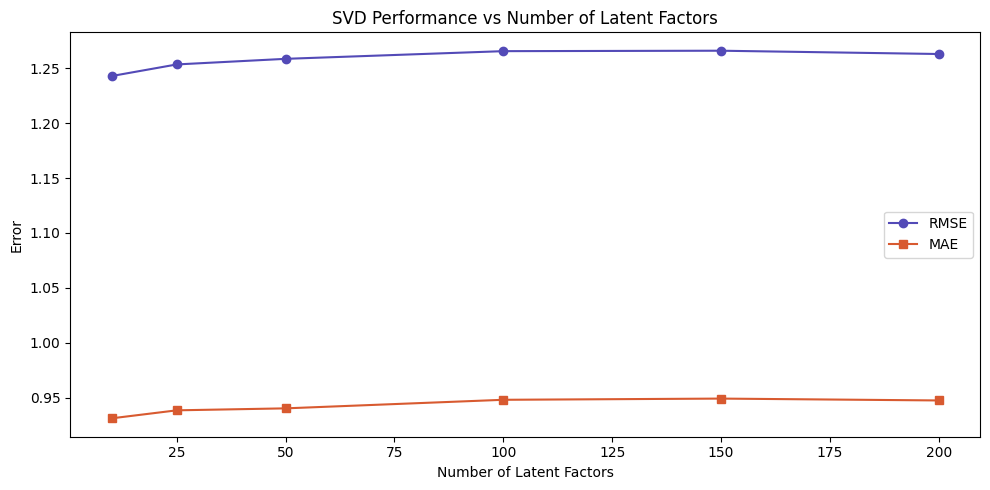

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(svd_results_df["n_factors"], svd_results_df["RMSE"], marker="o", color="#534AB7", label="RMSE")
ax.plot(svd_results_df["n_factors"], svd_results_df["MAE"], marker="s", color="#D85A30", label="MAE")
ax.set_xlabel("Number of Latent Factors")
ax.set_ylabel("Error")
ax.set_title("SVD Performance vs Number of Latent Factors")
ax.legend()
plt.tight_layout()
plt.savefig("svd_factor_tuning.png", dpi=150, bbox_inches="tight")
plt.show()

The results of this were quite interesting. Based on the plot above, the curve is relatively flat and we can see that 10 latent factors seems to achieve the lowest RMSE (1.23) and as the number of latent factors increase, the performance degrades slowly. This suggests that the dimensionality of the user taste in this dataset is low, since a small number of latent factors capture most of the signal. Therefore, I want to retrain the SVD model with 10 factors as it performs the best, and save this model.

In [ ]:
# Retrain the best SVD model and store it
best_svd = SVD(n_factors=10, n_epochs=20, random_state=42)
best_svd.fit(trainset)
preds_best = best_svd.test(testset)

rmse_best = accuracy.rmse(preds_best, verbose=False)
mae_best = accuracy.mae(preds_best, verbose=False)

results = pd.DataFrame({
    "Model": ["SVD (100 factors)", "SVD (10 factors) ★", "NMF (100 factors, no bias)", "NMF (30 factors, biased)"],
    "RMSE": [rmse_cf, rmse_best, rmse_nmf, rmse_nmf_tuned],
    "MAE": [mae_cf, mae_best, mae_nmf, mae_nmf_tuned],
})
results["RMSE"] = results["RMSE"].round(4)
results["MAE"] = results["MAE"].round(4)
results

,Model,RMSE,MAE
0,SVD (100 factors),1.2657,0.9480
1,SVD (10 factors) ★,1.2430,0.9311
2,"NMF (100 factors, no bias)",2.9162,2.3996
3,"NMF (30 factors, biased)",1.2856,0.9685


SVD at 10 factors is now confirmed as the best CF approach (RMSE 1.24). I want to see if combining it with content-based filtering can improve recommendation quality further.



---



## **Part 4: The Hybrid Model**

My content-based filtering works well for finding anime with similar genres but can't learn from user behavior. On the other hand, SVD captures behavioral patterns but struggles with niche anime that have few ratings. The goal of the hybrid model is to combine both signals.

My approach here is to, compute both a CF score (SVD predicted rating) and a content-based score (average cosine similarity to the user's highly-rated anime) for each candidate anime. Then I create a hybrid by using a weighted blend of the two models.

***The logic:***

Given a user,


1.   Look at anime that they have rated highly
2.   For each candidate anime, get the CF predicted rating from SVD
3.   For each candidate anime, get the content-based score
4.   Normalize both to the same scale and blend



Function to get the content-based score for a given user:

In [ ]:
def get_user_content_score(username, anime_id, user_ratings, cosine_sim_df):
    """
    For a given user, compute how similar anime_id is to the anime they've rated highly (score >= 8). Returns average cosine similarity.
    """
    # Get this user's highly rated anime
    user_top = user_ratings[
        (user_ratings["username"] == username) & (user_ratings["my_score"] >= 8)
    ]["anime_id"].values

    if len(user_top) == 0:
        return 0.0

    # Only compare with anime that exist in our similarity matrix
    valid = [a for a in user_top if a in cosine_sim_df.index]
    if len(valid) == 0 or anime_id not in cosine_sim_df.index:
        return 0.0

    # Average similarity between candidate and user's favorites
    similarities = cosine_sim_df.loc[anime_id, valid]
    return similarities.mean()

Hybrid recommender that blends both signals:

In [ ]:
def hybrid_recommend(username, n=10, alpha=0.6):

    # Get user's rated anime and favorites (score >= 8)
    user_data = ratings_clean[ratings_clean["username"] == username]
    user_rated = set(user_data["anime_id"])
    user_favs = user_data[user_data["my_score"] >= 8]["anime_id"].values

    # Candidates: anime in our similarity matrix that user hasn't rated
    all_anime = cosine_sim_df.index
    candidates = [a for a in all_anime if a not in user_rated]

    # Content-based scores: average similarity to favorites, all at once
    valid_favs = [a for a in user_favs if a in cosine_sim_df.index]
    if valid_favs:
        cb_scores = cosine_sim_df.loc[candidates, valid_favs].mean(axis=1)
    else:
        cb_scores = pd.Series(0, index=candidates)

    # CF scores: batch predict
    cf_preds = [best_svd.predict(username, a) for a in candidates]
    cf_scores = pd.Series([p.est for p in cf_preds], index=candidates)

    # Normalize CF to 0-1 and blend
    cf_normalized = (cf_scores - 1) / 9
    hybrid_scores = alpha * cf_normalized + (1 - alpha) * cb_scores

    # Top n results
    top_ids = hybrid_scores.sort_values(ascending=False).head(n).index

    results = anime_clean[anime_clean["anime_id"].isin(top_ids)].copy()
    results["cf_score"] = results["anime_id"].map(cf_scores).round(2)
    results["cb_score"] = results["anime_id"].map(cb_scores).round(3)
    results["hybrid_score"] = results["anime_id"].map(hybrid_scores).round(4)
    results = results.sort_values("hybrid_score", ascending=False)

    return results[["title", "title_english", "genre", "score", "cf_score", "cb_score", "hybrid_score"]]

I just want to test the hybrid model with a test user:

In [ ]:
# Pick a user who has enough ratings to test with
test_user = ratings_clean["username"].value_counts().index[0]
print(f"Testing with user: {test_user}")
print(f"Number of ratings: {ratings_clean[ratings_clean['username'] == test_user].shape[0]}")

Testing with user: landlock
Number of ratings: 1860


I also want to bring up this user's top rated anime to see what they enjoy and if the recommendations are relevant:

In [ ]:
user_top = ratings_clean[ratings_clean["username"] == "landlock"].merge(
    anime_clean[["anime_id", "title", "genre", "score"]], on="anime_id"
).sort_values("my_score", ascending=False).head(15)

user_top[["title", "genre", "my_score", "score"]]

,title,genre,my_score,score
428,Code Geass: Hangyaku no Lelouch,"Action, Military, Sci-Fi, Super Power, Drama, ...",10,8.79
1440,Kiseijuu: Sei no Kakuritsu,"Action, Sci-Fi, Horror, Psychological, Drama, ...",10,8.52
1352,Sidonia no Kishi,"Action, Mecha, Sci-Fi, Seinen, Space",10,7.80
75,Kimi ga Nozomu Eien,"Drama, Romance, Slice of Life",10,7.35
1770,Violet Evergarden,"Slice of Life, Drama, Fantasy",10,8.59
436,Kekkaishi,"Adventure, Comedy, Fantasy, Shounen",9,7.69
1760,Kingsglaive: Final Fantasy XV,Action,9,7.65
584,Soul Eater,"Action, Fantasy, Comedy, Supernatural, Shounen",9,8.03
136,Golden Boy,"Adventure, Comedy, Ecchi",9,8.04
1388,Sekai Seifuku: Bouryaku no Zvezda,"Action, Comedy, Fantasy",9,7.15


The initial hybrid implementation took 10-15 minutes per user due to row-by-row looping. Therefore, instead of looping through each user's favorites one at a time, I used pandas matrix slicing to grab the entire similarity column at once.

The system recommends these to this user:

In [ ]:
hybrid_recommend("landlock")

,title,title_english,genre,score,cf_score,cb_score,hybrid_score
5279,Isekai no Seikishi Monogatari,Tenchi Muyo! War on Geminar,"Action, Comedy, Ecchi, Fantasy, Harem, Mecha, ...",8.02,8.13,0.330,0.6077
7549,Pokemon: The Origin,Pokémon: Origins,"Action, Adventure, Comedy, Fantasy, Kids",7.89,8.34,0.285,0.6033
4244,Digimon Adventure tri. 3: Kokuhaku,Digimon Adventure tri. Confession,"Action, Adventure, Comedy, Drama",7.96,8.03,0.319,0.5965
51,Junjou Romantica,Junjo Romantica,"Comedy, Drama, Romance, Shounen Ai",7.99,8.33,0.267,0.5957
7354,There She Is!!,There She Is!!,"Comedy, Romance",8.03,8.16,0.291,0.5937
980,Digimon Adventure tri. 1: Saikai,Digimon Adventure tri. Reunion,"Action, Adventure, Comedy, Drama",7.62,7.77,0.319,0.5789
10861,Hayate no Gotoku!!,Hayate the Combat Butler!!,"Action, Harem, Comedy, Parody, Romance, Shounen",7.85,7.88,0.298,0.5781
10,Junjou Romantica 2,Junjo Romantica 2,"Comedy, Drama, Romance, Shounen Ai",8.15,8.05,0.267,0.5767
5371,Nanatsu no Taizai: Imashime no Fukkatsu,Nanatsu no Taizai: Imashime no Fukkatsu,"Action, Adventure, Supernatural, Magic, Fantas...",8.41,8.10,0.246,0.5716
7064,Mahou Shoujo Lyrical Nanoha StrikerS,Magical Girl Lyrical Nanoha StrikerS,"Action, Magic, Comedy, Super Power, Drama",7.72,7.83,0.281,0.5675


These recommendations seem to be pretty aligned with the tastes of the user, however this is my subjective assessment of it. I want to do a proper evaluation of the hybrid model and compare it against pure SVD on the same test set to see if blending is actually helping.

In [ ]:
from collections import defaultdict

# Group test set by user for efficient processing
test_by_user = defaultdict(list)
for uid, iid, true_r in testset:
    test_by_user[uid].append((iid, true_r))

# Evaluate on a sample of test users (full set would be slow)
sample_users = list(test_by_user.keys())[:200]

hybrid_errors = []
cf_errors = []

for user in sample_users:
    user_data = ratings_clean[ratings_clean["username"] == user]
    user_favs = user_data[user_data["my_score"] >= 8]["anime_id"].values
    valid_favs = [a for a in user_favs if a in cosine_sim_df.index]

    for anime_id, true_rating in test_by_user[user]:
        # Pure CF prediction
        cf_pred = best_svd.predict(user, anime_id).est
        cf_errors.append((cf_pred - true_rating) ** 2)

        # Hybrid prediction
        if valid_favs and anime_id in cosine_sim_df.index:
            cb_score = cosine_sim_df.loc[anime_id, valid_favs].mean()
        else:
            cb_score = 0.0

        cf_norm = (cf_pred - 1) / 9
        hybrid_pred = 0.6 * cf_norm + 0.4 * cb_score
        # Scale back to 1-10 for fair comparison
        hybrid_pred_scaled = hybrid_pred * 9 + 1
        hybrid_errors.append((hybrid_pred_scaled - true_rating) ** 2)

cf_rmse = np.sqrt(np.mean(cf_errors))
hybrid_rmse = np.sqrt(np.mean(hybrid_errors))

print(f"Pure CF (SVD 10 factors) RMSE: {cf_rmse:.4f}")
print(f"Hybrid (0.6 CF + 0.4 CB) RMSE: {hybrid_rmse:.4f}")

Pure CF (SVD 10 factors) RMSE: 1.1938
Hybrid (0.6 CF + 0.4 CB) RMSE: 2.1091


### Why score blending failed

The hybrid v1 RMSE (2.11) is significantly worse than pure CF (1.19). The problem: CF produces well-calibrated rating predictions (trained on a 1-10 scale), while the content-based score is a similarity metric (0-1 scale) that was never trained to predict ratings. Normalizing and mixing these fundamentally different quantities distorts the predictions.

This is a common finding in recommender system research. Naive score blending often hurts accuracy even when both components are individually useful.

**The insight:** the content-based model's value is in it's *ranking*. It surfaces relevant anime that CF might miss, especially for niche titles. So instead of blending scores, I should blend *ranks*.

In [ ]:
def hybrid_recommend_v2(username, n=10, cf_weight=0.7):
    """
    Updated hybrid model:
    - Rank primarily by CF predicted rating
    - Use content-based similarity as a tiebreaker/boost
    - Both scores stay in their natural scale
    - Shows the top rated anime suggestion for a franchise and eliminates multiple recommendations from the same franchise
    """
    user_data = ratings_clean[ratings_clean["username"] == username]
    user_rated = set(user_data["anime_id"])
    user_favs = user_data[user_data["my_score"] >= 8]["anime_id"].values

    candidates = [a for a in cosine_sim_df.index if a not in user_rated]

    valid_favs = [a for a in user_favs if a in cosine_sim_df.index]
    if valid_favs:
        cb_scores = cosine_sim_df.loc[candidates, valid_favs].mean(axis=1)
    else:
        cb_scores = pd.Series(0, index=candidates)

    cf_preds = [best_svd.predict(username, a) for a in candidates]
    cf_scores = pd.Series([p.est for p in cf_preds], index=candidates)

    cf_ranks = cf_scores.rank(pct=True)
    cb_ranks = cb_scores.rank(pct=True)
    hybrid_ranks = cf_weight * cf_ranks + (1 - cf_weight) * cb_ranks

    # Sort all candidates by hybrid rank
    sorted_ids = hybrid_ranks.sort_values(ascending=False).index

    # Deduplicate by franchise
    seen_franchises = set()
    results = []
    for aid in sorted_ids:
        if len(results) >= n:
            break
        info = anime_clean[anime_clean["anime_id"] == aid].iloc[0]
        franchise = get_franchise_key(info["title"])
        if franchise in seen_franchises:
            continue
        seen_franchises.add(franchise)
        results.append({
            "title": info["title"],
            "english_title": info["title_english"],
            "genre": info["genre"],
            "score": info["score"],
            "cf_score": round(cf_scores[aid], 2),
            "cb_score": round(cb_scores[aid], 3),
            "hybrid_rank": round(hybrid_ranks[aid], 4),
        })

    return pd.DataFrame(results)

In [ ]:
hybrid_recommend_v2("landlock")

,title,english_title,genre,score,cf_score,cb_score,hybrid_rank
0,Isekai no Seikishi Monogatari,Tenchi Muyo! War on Geminar,"Action, Comedy, Ecchi, Fantasy, Harem, Mecha, ...",8.02,8.13,0.330,0.9971
1,Digimon Adventure tri. 3: Kokuhaku,Digimon Adventure tri. Confession,"Action, Adventure, Comedy, Drama",7.96,8.03,0.319,0.9947
2,One Piece Film: Gold,One Piece Film: Gold,"Action, Adventure, Comedy, Drama, Fantasy, Sho...",8.14,7.46,0.340,0.9918
3,Great Teacher Onizuka,Great Teacher Onizuka,"Comedy, Drama, School, Shounen, Slice of Life",8.74,7.52,0.320,0.9901
4,Maison Ikkoku,Maison Ikkoku,"Slice of Life, Comedy, Drama, Romance, Seinen",8.24,7.56,0.315,0.9892
5,Ballroom e Youkoso,Welcome to the Ballroom,"Comedy, Sports, Drama, Romance, School, Shounen",8.34,7.59,0.311,0.9891
6,Dragon Ball Z Movie 12: Fukkatsu no Fusion!! G...,Dragon Ball Z Movie 12: Fusion Reborn,"Action, Sci-Fi, Adventure, Comedy, Fantasy, Sh...",7.69,7.37,0.332,0.9886
7,Sora no Otoshimono: Tokeijikake no Angeloid,Heaven&#039;s Lost Property the Movie: The Ang...,"Comedy, Drama, Ecchi, Harem, Romance, Sci-Fi, ...",7.78,7.27,0.339,0.9876
8,Bakuman. 2nd Season,Bakuman.,"Comedy, Drama, Romance, Shounen",8.49,7.65,0.305,0.9869
9,Hayate no Gotoku!!,Hayate the Combat Butler!!,"Action, Harem, Comedy, Parody, Romance, Shounen",7.85,7.88,0.298,0.9864


The rank-based fusion approach yields noticeably different results. Quality, lesser-known anime like Great Teacher Onizuka and Maison Ikkoku now appear. Previously these titles that were pure CF or pure content-based wouldn't surface on their own. The hybrid successfully combines CF's ability to predict user preferences with content-based filtering's ability to find genre-appropriate matches regardless of popularity.

## Summary

Below is a comparison of all the methods tested in this notebook:

In [ ]:
final_summary = pd.DataFrame({
    "Model": [
        "Content-Based (Cosine Similarity)",
        "SVD (100 factors)",
        "SVD (10 factors) ★",
        "NMF (100 factors, no bias)",
        "NMF (30 factors, biased)",
        "Hybrid v1 (score blending)",
        "Hybrid v2 (rank blending)",
    ],
    "RMSE": [
        "N/A (ranking only)",
        "1.2657",
        "1.2430",
        "2.9162",
        "1.2856",
        "2.1091",
        "N/A (ranking only)",
    ],
    "Strengths": [
        "No cold start, explainable, fast",
        "Strong baseline CF",
        "Best accuracy, simplest model",
        "Interpretable factors",
        "Near SVD accuracy with bias",
        "Combines both signals",
        "Best ranking diversity, no scale mismatch",
    ],
    "Weaknesses": [
        "Genre-only, misses behavioral patterns",
        "Slightly overparameterized",
        "Misses niche/long-tail anime",
        "Needs bias terms for skewed data",
        "Slightly worse than SVD",
        "Score blending hurts accuracy",
        "Can't evaluate via RMSE",
    ],
})
final_summary

,Model,RMSE,Strengths,Weaknesses
0,Content-Based (Cosine Similarity),N/A (ranking only),"No cold start, explainable, fast","Genre-only, misses behavioral patterns"
1,SVD (100 factors),1.2657,Strong baseline CF,Slightly overparameterized
2,SVD (10 factors) ★,1.2430,"Best accuracy, simplest model",Misses niche/long-tail anime
3,"NMF (100 factors, no bias)",2.9162,Interpretable factors,Needs bias terms for skewed data
4,"NMF (30 factors, biased)",1.2856,Near SVD accuracy with bias,Slightly worse than SVD
5,Hybrid v1 (score blending),2.1091,Combines both signals,Score blending hurts accuracy
6,Hybrid v2 (rank blending),N/A (ranking only),"Best ranking diversity, no scale mismatch",Can't evaluate via RMSE


### Key takeaways

1. **Bias correction is essential for skewed rating data:** NMF without bias terms failed dramatically (RMSE 2.92) because MAL ratings cluster around 7-8. Adding bias terms brought it within a close distance of SVD.

2. **Fewer latent factors can outperform more:** SVD with just 10 factors beat 100, 150, and 200 factors. This tells us that the effective dimensionality of anime taste preferences is surprisingly low.

3. **Naive score blending hurts accuracy:** Mixing calibrated predictions with uncalibrated similarity scores makes both worse. Rank-based fusion respects each model's strengths without forcing them onto the same scale.

4. **Content-based filtering's value is in coverage, not accuracy:** On its own, it can't compete with CF for rating prediction. But it surfaces niche, genre-appropriate titles that CF would never find. This is exactly the complementary strength a hybrid model needs to provide an array of suitable shows to the user.

### What I built with these findings

Using the best-performing models from this analysis, I built a web application with three entry points:
- **Title picker** - select anime you've enjoyed, get content-based recommendations
- **Genre picker** - choose genres you're interested in for cold-start users
- **MAL username lookup** - enter your username for personalized hybrid recommendations combining SVD and content-based filtering

The application is deployed at https://mal-recommender.onrender.com/ and demonstrates how the analytical findings in this notebook translate to a usable product.

### Future improvements
- **Better franchise deduplication**: the current 2-word heuristic misses cases like "Fullmetal Alchemist" vs "FMA: Brotherhood". Furthemore, it will also miss cases where the franchise title appears after the first two words of the title. (E.g. "Steel Ball Run - Jojo's Bizarre Adventure". The franchise title here is "Jojo's Bizarre Adventure" and "Steel Ball Run" refers to one particular season of the show.)  
- **Richer content features**: incorporate studio, source material, and synopsis text (via TF-IDF or embeddings) beyond just genres
- **Live MAL integration**: use the Jikan API to fetch any user's current ratings instead of relying on a static dataset snapshot
- **A/B testing different alpha weights**: the 70/30 CF/CB split was chosen heuristically; user feedback could optimize this